In [8]:
import EFC_learningfMRI.globals as gl
import os
import numpy as np
import matplotlib.pyplot as plt
import PcmPy as pcm
from scipy.linalg import orthogonal_procrustes
from EFC_learningfMRI.G_matrix import G_sorted
from EFC_learningfMRI.util import get_trained_and_untrained
import warnings

warnings.filterwarnings('ignore')


In [9]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
sns   = gl.participants

markers = ['o', 's', '^', 'v', 'D', 'P', 'X', '*']   # one per chord, in gl.chordID order


# MDS of the chord geometry

`G_obs_raw` is estimated without the partition fixed effect, so the mean pattern is still in G and
`pcm.classical_mds` returns uncentred coordinates: **dim 0 is the activity axis** (distance along it is
the pattern norm) and the later dims carry the chord geometry. Dim 0 is 47-71x larger than dim 1, so
plots that include it come out as a flat sheet -- that is what `dims` controls below.

Classical MDS fixes a configuration only up to a rotation/reflection, and each participant gets a
different one, so every participant is Procrustes-aligned to a group reference before averaging. The
coordinates are uncentred, so the alignment must **not** translate: `W @ W.T == G` pins them down only
up to `W -> W @ Q` for orthogonal `Q`, i.e. rotation about the origin. `orthogonal_procrustes` does
exactly that, and no centring is applied.

Each chord is trained in about half the participants, so it gets two markers: red is the mean over the
participants who trained it, blue over those who did not.

**Reading session 3.** Red and blue are averages over *disjoint* groups of ~7 and ~6 people, so they are
not expected to coincide even at baseline -- the expected gap is about `0.44 x SD`, and a label-shuffling
permutation test puts the observed session-3 gaps at or below their null in every ROI and on every axis.
Session 3 is therefore the noise floor to read sessions 9 and 23 against, not a check on the alignment.


In [10]:
def align_mds(roi, sess, dims):
    """Per-participant MDS at (roi, sess), Procrustes-aligned to the group frame.

    The reference is the MDS of the group-average G for that ROI and session, built once in
    gl.chordID order; only its rows are permuted per participant, never recomputed, so every
    participant is aligned to the same axes. (Recomputing it per participant flips eigenvector
    signs and lands participants in mirrored frames.)

    Args:
        roi, sess: ROI name and session.
        dims:      slice of MDS dimensions to keep. The Procrustes fit uses these same
                   dimensions, so changing it changes the alignment, not only the view.

    Returns:
        coords:     (n_subj, 8, n_dims) coordinates, chords in gl.chordID order.
        is_trained: (n_subj, 8) True where that participant trained that chord.
    """
    G = np.array([np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}',
                  f'G_obs_raw.within_session.{sess}.glm{glm}.{H}.{roi}.npy')) for sn in sns])

    mds_ref, _ = pcm.classical_mds(G_sorted(G, sns, order=gl.chordID).mean(axis=0))
    mds_ref    = mds_ref[:, dims]

    coords, is_trained = [], []
    for i, sn in enumerate(sns):
        order = np.asarray(get_trained_and_untrained(sn), dtype=int)
        perm  = [list(gl.chordID).index(c) for c in order]   # reference rows -> sn's order

        mds, _ = pcm.classical_mds(G[i])                     # G[i] is already in sn's own order
        R, _   = orthogonal_procrustes(mds[:, dims], mds_ref[perm])
        mdsa   = mds[:, dims] @ R

        coords.append(mdsa[np.argsort(perm)])                # back to gl.chordID order
        is_trained.append(np.isin(gl.chordID, order[:4]))

    return np.array(coords), np.array(is_trained)


def chord_means(coords, is_trained, c):
    """Chord c averaged over the participants who trained it, and over those who did not.

    The two groups are disjoint sets of participants (~7 and ~6), so the error is a
    between-participant SEM, not a within-participant one.

    Returns:
        m:  (2, n_dims) mean position, row 0 trained, row 1 untrained.
        se: (2, n_dims) SEM over the participants in each group.
    """
    m, se = [], []
    for t in (True, False):
        g = coords[is_trained[:, c] == t, c]
        m.append(g.mean(axis=0))
        se.append(g.std(axis=0, ddof=1) / np.sqrt(len(g)))
    return np.array(m), np.array(se)


## 2D: two geometry dimensions

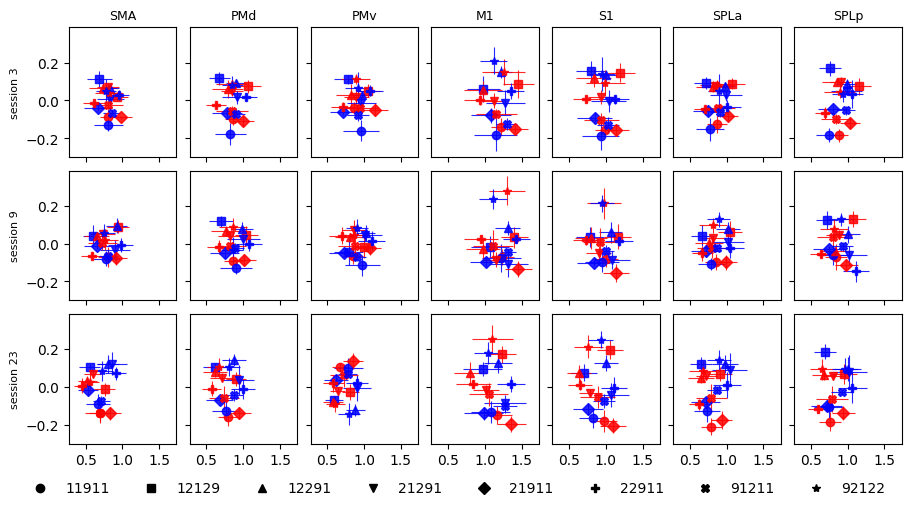

In [11]:
dims = slice(0, 2)   # slice(0, 2) puts the activity axis on x; slice(1, 3) is geometry only

fig, axs = plt.subplots(3, len(rois), sharex=True, sharey=True, constrained_layout=True, figsize=(9, 5))

for r, roi in enumerate(rois):
    for s, sess in enumerate(gl.sessions):
        ax = axs[s, r]
        coords, is_trained = align_mds(roi, sess, dims)

        for c in range(len(gl.chordID)):
            m, se = chord_means(coords, is_trained, c)
            for i, color in enumerate(('r', 'b')):
                ax.errorbar(*m[i], xerr=se[i, 0], yerr=se[i, 1], marker=markers[c], ls='', ms=6,
                            color=color, ecolor=color, elinewidth=.8, alpha=.85, zorder=1e6)

        ax.set_title(roi, fontsize=9) if s == 0 else None
        ax.set_ylabel(f'session {sess}', fontsize=8) if r == 0 else None

fig.legend(handles=[plt.Line2D([], [], ls='', marker=mk, color='k', label=str(ch))
                    for mk, ch in zip(markers, gl.chordID)],
           frameon=False, loc='outside lower center', ncol=8)

fig.savefig('figures/mds_trained_untrained_2d.pdf')

plt.show()


## 3D: the first three dimensions

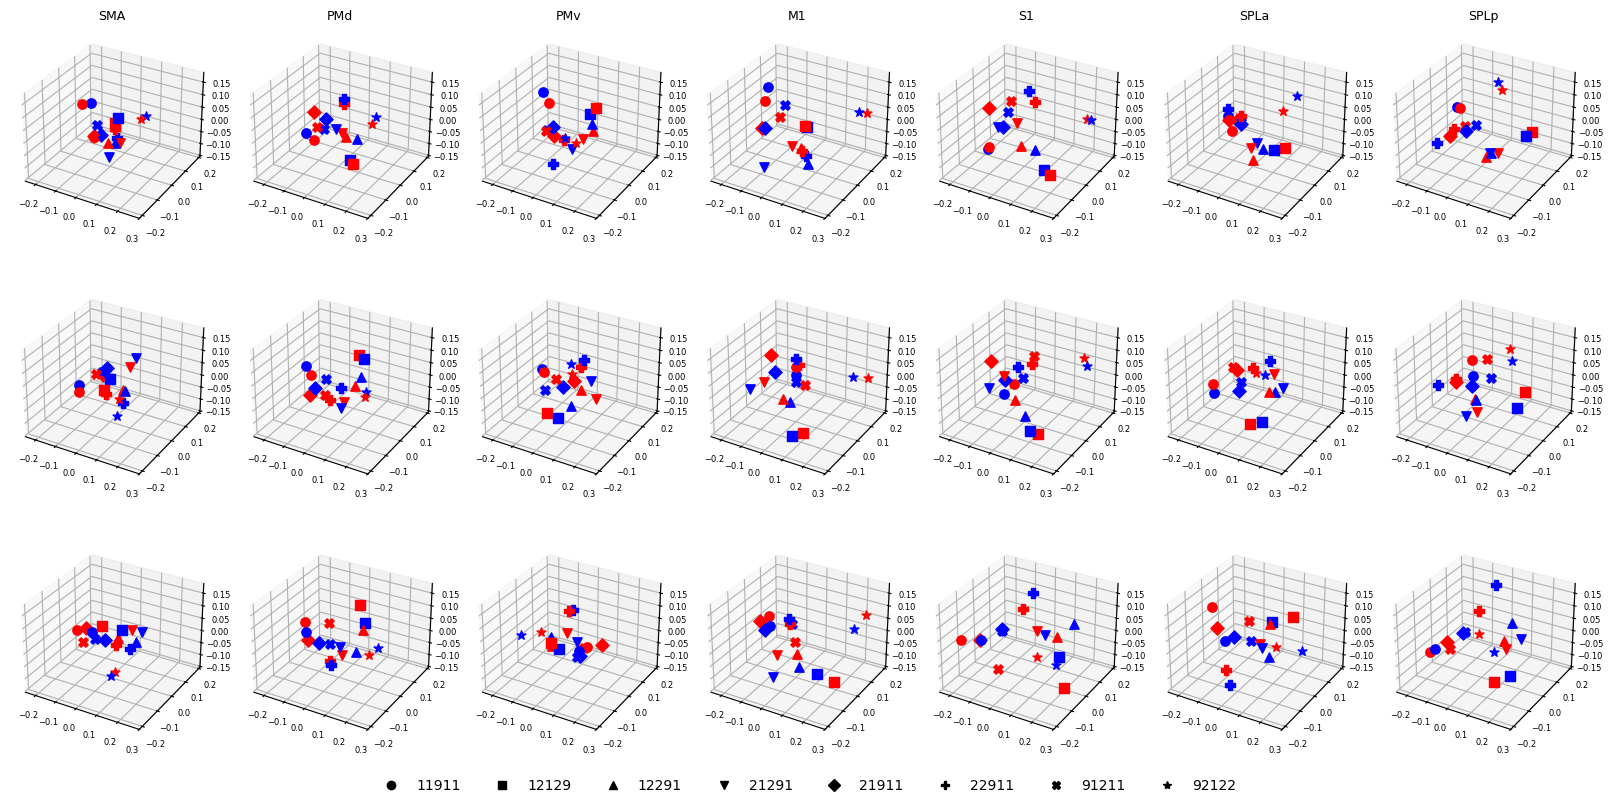

In [12]:
dims = slice(1, 4)   # first three; slice(1, 4) drops the activity axis

fig, axs = plt.subplots(3, len(rois), constrained_layout=True,
                        figsize=(16, 8), subplot_kw={'projection': '3d'})

pts = []                # every point drawn, to set common limits at the end

for r, roi in enumerate(rois):
    for s, sess in enumerate(gl.sessions):
        ax = axs[s, r]
        coords, is_trained = align_mds(roi, sess, dims)

        for c in range(len(gl.chordID)):
            m, _ = chord_means(coords, is_trained, c)
            for i, color in enumerate(('r', 'b')):
                ax.scatter(*m[i], color=color, s=45, marker=markers[c], zorder=1e6)
                pts.append(m[i])

        ax.tick_params(labelsize=6, pad=0)
        ax.set_title(roi, fontsize=9) if s == 0 else None

# 3d axes ignore sharex/sharey when autoscaling, so give every panel the same limits by hand
pts    = np.array(pts)
lo, hi = pts.min(axis=0), pts.max(axis=0)
pad    = .05 * (hi - lo)
for ax in axs.flat:
    ax.set_xlim(lo[0] - pad[0], hi[0] + pad[0])
    ax.set_ylim(lo[1] - pad[1], hi[1] + pad[1])
    ax.set_zlim(lo[2] - pad[2], hi[2] + pad[2])

fig.legend(handles=[plt.Line2D([], [], ls='', marker=mk, color='k', label=str(ch))
                    for mk, ch in zip(markers, gl.chordID)],
           frameon=False, loc='outside lower center', ncol=8)

fig.savefig('figures/mds_trained_untrained_3d.pdf')

plt.show()
